In [2]:
#Importing all the necessary values
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt
import seaborn as sns

In [3]:
#Loading the dataset
data = pd.read_csv("C:/Users/preet/Downloads/bank-full.csv",sep=';')

In [4]:
#Converting the dataset into a pandas DataFrame 
df = pd.DataFrame(data)

In [5]:
#Observing the top 5 entries in the dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
#Analyzing the different types of each category
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [7]:
#Checking for duplicate entries
df.duplicated().sum()

np.int64(0)

In [8]:
#Classifying the different categories into binary, multi-category, and numerical categories

binary_columns = ["default", "housing", "loan"]

categorical_columns = ["job", "marital", "education", "contact", "month", "poutcome"]

numerical_columns = ["age", "balance", "day", "campaign", "pdays", "previous"]

In [9]:
#Checking for missing values in binary categories
df[binary_columns].isna().sum()
for column in binary_columns:
    print((df[column]=='unknown').sum())
    print((df[column]=='unknown').sum()/df[column].count().sum())

0
0.0
0
0.0
0
0.0


In [10]:
#Checking for missing values in categorical categories
df[categorical_columns].isna().sum()
for column in categorical_columns:
    print((df[column]=='unknown').sum())
    print((df[column]=='unknown').sum()/df[column].count().sum())

288
0.006370131162770122
0
0.0
1857
0.04107407489327818
13020
0.28798301298356593
0
0.0
36959
0.8174780473778506


In [11]:
#Checking for missing values in numerical categories
df[numerical_columns].isna().sum()

age         0
balance     0
day         0
campaign    0
pdays       0
previous    0
dtype: int64

In [12]:
#Observing the distribution of values of the missing value categories
#Performing one-hot encoding so that meaningful data is not lost
missing_categories = ['job', 'education', 'contact', 'poutcome']
for column in missing_categories:
    print((df[column]=='unknown').sum()/df[column].count().sum())

0.006370131162770122
0.04107407489327818
0.28798301298356593
0.8174780473778506


In [13]:
# Drop 'duration' because it is only known after the call is completed.
# Including it would cause target leakage and make the model unrealistic
# for predicting customer subscription before contacting them.
df = df.drop(columns='duration')

In [14]:
#Binary encoding for binary-valued categories
for column in binary_columns:
    df[column] = df[column].map({
        "no": 0,
        "yes": 1
    })

df["y"] = df["y"].map({
    "no": 0,
    "yes": 1
})

In [15]:
#Performing one-hot encoding on all multi-valued categories
df = pd.get_dummies(
    df, 
    columns=categorical_columns, 
    dtype=int)

In [16]:
#Performing outlier analysis and checking for invalid data
outlier_summary = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "feature": column,
        "minimum": df[column].min(),
        "maximum": df[column].max(),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_count / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

 feature  minimum  maximum  lower_bound  upper_bound  outlier_count  outlier_percentage
     age       18       95         10.5         70.5            487            1.077171
 balance    -8019   102127      -1962.0       3462.0           4729           10.459844
     day        1       31        -11.5         40.5              0            0.000000
campaign        1       63         -2.0          6.0           3064            6.777112
   pdays       -1      871         -1.0         -1.0           8257           18.263255
previous        0      275          0.0          0.0           8257           18.263255


In [17]:
#The 'pdays' category represents when a customer was last contacted
#-1 in this column represents that a customer was never contacted
#So we create another column representing if a customer was ever contacted or not
#We keep both columns so that crucial data regarding customer contact is not lost
df["previously_contacted"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

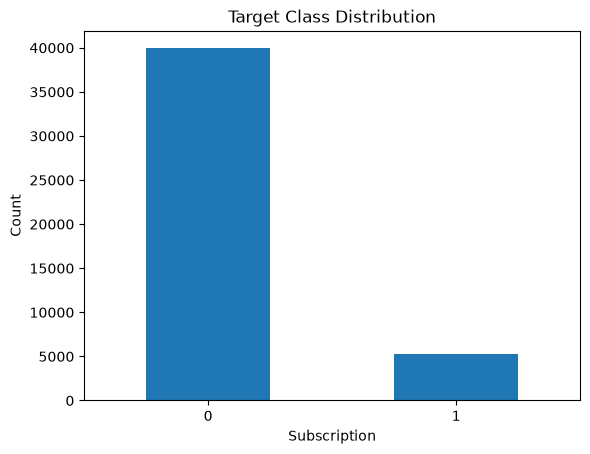

In [18]:
#The target variable is moderately imbalanced, with a larger proportion of customers who did not subscribe to the term than those who did
#The train-test split will also be stratified to preserve the original class distribution in both datasets.
df["y"].value_counts(normalize=True) * 100
df["y"].value_counts().plot(
    kind="bar",
    rot=0
)

pt.title("Target Class Distribution")
pt.xlabel("Subscription")
pt.ylabel("Count")
pt.show()

In [19]:
#Observing the final modified and engineered DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   45211 non-null  int64
 1   default               45211 non-null  int64
 2   balance               45211 non-null  int64
 3   housing               45211 non-null  int64
 4   loan                  45211 non-null  int64
 5   day                   45211 non-null  int64
 6   campaign              45211 non-null  int64
 7   pdays                 45211 non-null  int64
 8   previous              45211 non-null  int64
 9   y                     45211 non-null  int64
 10  job_admin.            45211 non-null  int64
 11  job_blue-collar       45211 non-null  int64
 12  job_entrepreneur      45211 non-null  int64
 13  job_housemaid         45211 non-null  int64
 14  job_management        45211 non-null  int64
 15  job_retired           45211 non-null  int64
 16  job_self-employ

In [ ]:
#Getting counts of the target variable values
df["y"].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [ ]:
#Getting % of the target variable values
(df["y"].value_counts(normalize=True) * 100).round(2)

y
0    88.3
1    11.7
Name: proportion, dtype: float64

Although several numerical variables contain statistical outliers according to the IQR rule, these observations correspond to valid customer behaviour rather than data-entry errors. Since Decision Trees are robust to extreme values, no observations were removed based solely on the IQR criterion.

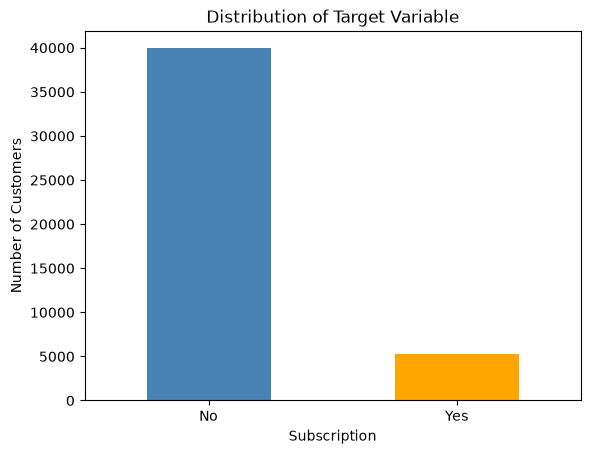

In [ ]:
#Visualizing the target variable distribution
import matplotlib.pyplot as plt

class_counts = df["y"].value_counts()

class_counts.plot(kind="bar", color=["steelblue", "orange"])

plt.title("Distribution of Target Variable")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.xticks([0,1], ["No", "Yes"], rotation=0)
plt.show()

The target variable is imbalanced, with approximately 88% of customers not subscribing to the term deposit and 12% subscribing. Because of this imbalance, model performance will not be evaluated using accuracy alone. Additional metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will be used. Furthermore, a stratified train-test split will be performed to preserve the class distribution in both the training and testing datasets.

In [25]:
df.to_csv('./cleaned_marketing.csv')